### Importing the libraries


In [5]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F


### Root  data directory path

In [6]:
data_dir = r"D:\HIMANSHU\Projects\signature_recognition\notebook\data"

### Total number of the classes

In [7]:
class_name = os.listdir(data_dir)
len(class_name)

2

In [8]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T,datasets

### Checking cuda availiability

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:{}".format(device))

Device:cuda


### Transforming  the data

In [10]:
data_transform = T.Compose([
                            T.Resize(size=(224,224)),             # resizing the image to be 224 by 224
                            T.RandomRotation(degrees =(-20,+20)), # randomly rotate the images by+/-20 degree , uses Image arsumentation
                            T.ToTensor(),         # converting the dimension from (height,weight,channel) to (channel,height,weight)
                            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])  # npormalize by three means and three std's of the image net
])

In [11]:
data = datasets.ImageFolder(data_dir,transform=data_transform)
total_count= len(data)

In [12]:
total_count

2640

In [13]:
data.classes

['Forged', 'Original']

### Spliting the data


In [14]:
train_count=int(0.6*total_count)
valid_count =int(0.3*total_count)
test_count=total_count-train_count-valid_count
train_data,val_data,test_data = torch.utils.data.random_split(data,(train_count,valid_count,test_count))


In [15]:
len(train_data.indices)

1584

In [16]:
len(val_data.indices)

792

In [17]:
len(test_data.indices)

264

In [18]:
def show_image(image,label,get_denormalize=True):
    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485,0.456,0.406])
    std = torch.FloatTensor([0.229,0.224,0.225])

    if get_denormalize==True:
        image=image*std + mean
        image=np.clip(image,0,1)
        plt.imshow(image)
        plt.title(label)
        
    else:
        plt.imshow(image)
        plt.title(label)


def accuracy(y_pred,y_true):
    y_pred=F.softmax(y_pred,dim=1)
    top_p,top_class =y_pred.topk(1,dim=1)
    equals=top_class==y_true.value(*top_class.shape)

    return torch.mean(equals.type(torch.FloteTensor))
    


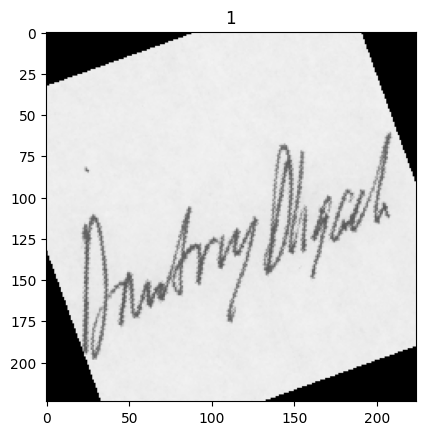

In [19]:
img,label=train_data[0]
show_image(img,label)

### Data Loader

In [20]:
trainloader = DataLoader(train_data,batch_size=32,shuffle=True)
print("no of batches in trainloader:{}".format(len(trainloader)))
print("no of Total examples:{}".format(len(trainloader.dataset)))

validationloader = DataLoader(val_data,batch_size=32,shuffle=True)
print("no of batches in trainloader:{}".format(len(validationloader)))
print("no of Total examples:{}".format(len(validationloader.dataset)))

testloader = DataLoader(test_data,batch_size=32,shuffle=False)
print("no of batches in trainloader:{}".format(len(testloader)))
#print("no of Total examples:{}".format(len(testloader.dataset)))
print(f"no of Total examples:{len(testloader.dataset)}")


no of batches in trainloader:50
no of Total examples:1584
no of batches in trainloader:25
no of Total examples:792
no of batches in trainloader:9
no of Total examples:264


### Model

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
import torchvision.transforms as transforms

In [22]:
model=models.resnet34(pretrained=True)

D:\HIMANSHU\Projects\signature_recognition\SR\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\HIMANSHU\Projects\signature_recognition\SR\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [23]:
# only final classification layer / last (fully connected) layer

model.fc=nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features,len(class_name))
)
model = model.to(device)

criterian= torch.nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(model.parameters(),lr=1e-3,momentum=0.9)

In [24]:
def train(model,criterian ,optimizer ,train_dataloader ,test_dataloader):

    total_train_loss=0
    total_test_loss =0

    model.train()
    with tqdm(train_dataloader,unit='batch' , leave=False) as pbar:
        pbar.set_description(f'training')
        for images ,idxs in pbar:
            images = images.to(device,non_blocking=True)
            idxs = idxs.to(device,non_blocking=True)
            output = model(images)
            
            loss = criterian(output,idxs)
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

    model.eval()
    with tqdm(test_dataloader,unit='batch' , leave=False) as pbar:
        pbar.set_description(f'testing')
        for images ,idxs in pbar:
            images = images.to(device,non_blocking=True)
            idxs = idxs.to(device,non_blocking=True)
            output = model(images)
            


    train_acc = total_train_loss / len(train_data)
    test_acc = total_test_loss / len(val_data)
    print(f"Train loss:{train_acc:.4f} Test_loss :{test_acc:.4f}")

    

In [25]:
%%time
epochs=5
for i in range(epochs):
    print(f"Epoches {i+1}/{epochs}")
    train(model,criterian ,optimizer ,trainloader ,validationloader )

Epoches 1/5


Train loss:0.0070 Test_loss :0.0000
Epoches 2/5


Train loss:0.0012 Test_loss :0.0000
Epoches 3/5


Train loss:0.0004 Test_loss :0.0000
Epoches 4/5


Train loss:0.0002 Test_loss :0.0000
Epoches 5/5


Train loss:0.0003 Test_loss :0.0000
CPU times: total: 14min 55s
Wall time: 3min 30s


### Model saving

In [29]:
Path = r"D:\\HIMANSHU\\Projects\\signature_recognition\\notebook\\model.pt"
torch.save(model,Path)

In [ ]:
pwd


### Loading torch model



In [32]:
model = torch.load(Path, weights_only=False)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Model Evaluation

In [40]:
def evaluate(model,criterian ,optimizer ,test_dataloader):
    total_test_loss = 0

    model.eval()
    with tqdm (test_dataloader ,unit ='batch' , leave = False) as pbar :
        pbar.set_description(f'testing')
        for  images ,idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterian(output,idxs)    
            total_test_loss += loss.item()   
        
    test_acc = total_test_loss / len(val_data)
    
    print(f"Test loss:{test_acc:.4f} ")            
            

           
        

In [41]:
evaluate(model,criterian ,optimizer ,testloader)

Test loss:0.0001 


### Prediction

In [42]:
label_name = data.classes
label_name

['Forged', 'Original']

In [46]:
from PIL import Image
image = Image.open(r'D:\HIMANSHU\Projects\signature_recognition\notebook\data\Original\original_1_1.png')
preprocess = transforms.Compose([
    transforms.Resize(size = (224,224)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

image = preprocess(image)
image = image[:3]

image =image.unsqueeze(0).to(device)

with torch.no_grad():
    logits =model(image)
    probs = torch.softmax(logits ,dim=1)
    pred_label =torch.argmax(probs ,dim=1)

print(f'predicted label:{pred_label.item()}')

predicted_class_name = label_name[pred_label.item()]

print(f'predicted class name :{predicted_class_name}')

predicted label:1
predicted class name :Original
